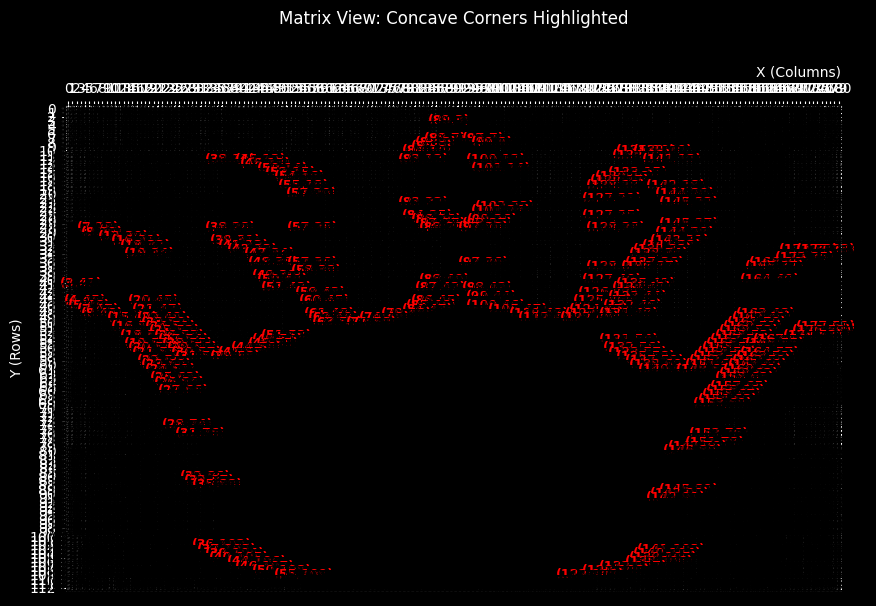

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def find_concave_corners(grid):
    rows, cols = grid.shape
    concave_points = []

    for y in range(1, rows - 1):
        for x in range(1, cols - 1):
            if grid[y, x] == 1:
                # Direct neighbors (Up, Down, Left, Right)
                t, b = grid[y-1, x], grid[y+1, x]
                l, r = grid[y, x-1], grid[y, x+1]

                # Diagonal neighbors
                tl, tr = grid[y-1, x-1], grid[y-1, x+1]
                bl, br = grid[y+1, x-1], grid[y+1, x+1]

                # A pixel is concave if it has two orthogonal neighbors (1)
                # but their shared diagonal is background (0)
                is_concave = (
                    (t == 1 and l == 1 and tl == 0) or
                    (t == 1 and r == 1 and tr == 0) or
                    (b == 1 and l == 1 and bl == 0) or
                    (b == 1 and r == 1 and br == 0)
                )

                if is_concave:
                    concave_points.append((x, y))

    return concave_points

def draw_matrix_visualization(grid, concave_points):
    rows, cols = grid.shape

    # Using matshow for native matrix display (origin at top-left)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.matshow(grid, cmap='Greys', alpha=0.2)

    for y in range(rows):
        for x in range(cols):
            # Coordinates text (x, y)
            label = f"({x},{y})"

            # Determine color: Red for concave corners, black/grey for others
            if (x, y) in concave_points:
                ax.text(x, y, label, ha='center', va='center',
                        color='red', fontweight='bold', fontsize=9)
                # Add a red circle to highlight the concave pixel
                circle = plt.Circle((x, y), 0.3, color='red', fill=False, lw=1.5)
                ax.add_patch(circle)
            else:
                ax.text(x, y, label, ha='center', va='center',
                        color='black', fontsize=8)

    # Styling to look like a matrix
    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))
    ax.set_xlabel('X (Columns)', loc='right')
    ax.set_ylabel('Y (Rows)')
    ax.xaxis.set_ticks_position('top') # X-axis at the top
    ax.xaxis.set_label_position('top')

    plt.title("Matrix View: Concave Corners Highlighted", pad=30)
    plt.show()

# Input Image
# img = np.array([
#     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
#     [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
#     [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
#     [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
#     [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
#     [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
#     [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
#     [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
#     [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
# ])

from pathlib import Path
img = np.load(
    "../../data/datasets/objects_binary/npy/crown-6_binary.npy"
)
img = (img > 0).astype(int)


# Execute
concave_list = find_concave_corners(img)
draw_matrix_visualization(img, concave_list)